# ProPicker: Architecture, Methodology and Results

## 1. Summary

ProPicker is a promptable, deep learning-based 3D segmentation model designed for particle picking in Cryogenic Electron Tomography (cryo-ET). Unlike traditional methods that rely purely on exhaustive template matching or static object detection models trained on fixed classes, ProPicker utilizes a "promptable" architecture. It takes a single example (a prompt) of a target particle and a tomogram volume as input to generate a 3D segmentation mask. This allows for zero-shot detection of unseen particles and highly data-efficient fine-tuning.

## 2. System Architecture

ProPicker decouples the feature extraction of the target particle from the segmentation of the volume. The architecture consists of two primary modules: a Prompt Encoder ($\epsilon$) and a Conditional Segmentation Network ($\mathcal{S}$).

### 2.1. The Prompt Encoder

The prompt encoder is responsible for generating a latent representation of the target particle.

- **Definition**: The encoder is defined as a function $\epsilon: \mathbb{R}^{m \times m \times m} \rightarrow \mathbb{R}^d$.
- **Input**: A small 3D crop (sub-tomogram) containing the particle of interest (the prompt), typically sized $37 \times 37 \times 37$ voxels.
- **Model**: ProPicker utilizes the TomoTwin encoder.
- **Output**: A feature vector $\epsilon(p) \in \mathbb{R}^{d}$, where $d=32$ in the implementation.
- **Function**: This vector encodes the structural identity of the particle. During training and inference, this encoder is typically frozen, ensuring consistent embeddings.

### 2.2. Conditional Segmentation Model (3D U-Net)

The core of ProPicker is a modified 3D U-Net that performs voxel-wise binary classification.

- **Definition**: The model is a function $\mathcal{S}: \mathbb{R}^{n \times n \times n} \times \mathbb{R}^d \rightarrow \mathbb{R}^{n \times n \times n}$.
- **Output**: It produces an output map $y = \mathcal{S}(x; \epsilon(p))$, where theoretically $y \in \{0, 1\}^{n \times n \times n}$ (implemented as a probability map via a sigmoid activation).
- **Architecture Base**: A 3D U-Net following the encoder-decoder structure, significantly scaled up from standard implementations (e.g., DeepETPicker).
- **Parameters**: Approximately $100$ million trainable parameters.
- **Depth**: 5 convolution-based spatial downsampling layers (Encoder) and 5 spatial upsampling layers (Decoder).
- **Channel Widths**: The layers process volumes with $108$, $216$, $432$, and $864$ channels respectively.
- **Normalization**: Instance Normalization is used instead of Batch Normalization. This is critical for processing large 3D volumes where batch sizes must be kept small due to memory constraints.

### 2.3. Conditioning Mechanism (FiLM)

To steer the generic U-Net to detect only the particle specified by the prompt, ProPicker uses Feature-wise Linear Modulation (FiLM).

- **Location**: FiLM layers are applied to each of the 5 spatial upsampling layers in the Decoder.
- **Mechanism**:
  - Let $c$ be the number of channels in an intermediate feature map. The 32-dim prompt vector $\epsilon(p)$ is projected using two learnable matrices $A, B \in \mathbb{R}^{c \times d}$.
  - This generates channel-specific modulation parameters: a slope $(A\epsilon(p))_k$ and an intercept $(B\epsilon(p))_k$ for each channel $k$.
  - For a feature map $F$ with $c$ channels, the modulation is applied as:

$$\text{FiLM}(F_k) = (A\epsilon(p))_k \cdot F_k + (B\epsilon(p))_k$$

This effectively highlights features in the activation maps that correlate with the geometric structure of the prompt while suppressing irrelevant features.

## 3. Operational Workflow

### 3.1. Inference (Prompt-Based Picking)

1. **Prompt Selection**: A user selects a sub-tomogram containing the target particle.
2. **Embedding**: The Prompt Encoder converts this into the vector $\epsilon(p)$.
3. **Sliding Window Segmentation**:
   - Since tomograms are too large to process at once, a window (default size $64 \times 64 \times 64$) slides across the volume.
   - **Stride**: A large stride (default $32$ voxels) is used. Unlike template matching which requires single-voxel strides (e.g., $s=1$ or $s=2$), the segmentation approach allows for larger steps, significantly increasing speed.
   - Overlapping predictions are averaged to produce a full-volume probability map.
4. **Coordinate Extraction**:
   - **ProPicker-C (Clustering)**: The segmentation mask $y$ is binarized. Connected components are analyzed to find centroids. Clusters falling outside specific size thresholds are discarded.
   - **ProPicker-TM (Template Matching)**: Used for difficult, crowded scenes. The segmentation mask acts as a region-of-interest filter. A template matcher is run only inside the masked regions to separate overlapping particles.

### 3.2. Training Methodology

- **Dataset**: Trained on 85 synthetic tomograms containing 121 unique protein types.
- **Procedure**:
  - **Input**: Batches of 8 sub-tomograms ($64^3$).
  - **Prompts**: 8 random prompts are sampled per batch.
  - **Loss**: Binary Cross Entropy (BCE) is calculated between the predicted mask and the ground truth mask for the specific prompted particle.
  - **Note**: The authors found BCE superior to Dice loss for this specific architecture, particularly in avoiding merged masks in crowded environments.

### 3.3. Fine-Tuning

When zero-shot performance is insufficient, ProPicker supports "Few-Shot" fine-tuning.

- **Frozen Components**: The Prompt Encoder weights and the Prompt vector $\epsilon(p)$ remain fixed.
- **Trainable Components**: The 3D U-Net weights $\mathcal{S}$ are updated.
- **Data Efficiency**: Experiments show that fine-tuning on as little as $25\%$ of a single tomogram can boost F1 scores significantly (e.g., from $\approx 0.15$ to $\approx 0.70$), outperforming models like DeepETPicker that require training from scratch.

## 4. Performance Characteristics

- **Generalization**: Capable of detecting unseen particles in synthetic data and diverse real-world datasets (e.g., DS-10440, EMPIAR-10988).
- **Speed**: By leveraging 3D segmentation with large strides, it achieves higher throughput (tomograms per hour) compared to dense template matching methods.
- **Limitations**: Like many deep learning methods, zero-shot performance can degrade on very small or low-contrast particles (e.g., beta-amylase) without fine-tuning. It relies on the existence of at least one clear example to serve as a prompt.

## 5. Prompt-Based Picking with ProPicker

In this notebook, we pick ribosomes in a single (defocus-only) tomogram contained in the EMPIAR-10988 dataset.

> Tested on an RTX2060Super GPU

In [ ]:
import sys
from pathlib import Path

# Add project root and experiments to path
PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

# Import paths (file system locations)
from paths import (
    PROPICKER_MODEL_FILE,
    TOMOTWIN_MODEL_FILE,
    EMPIAR10988_BASE_DIR,
)

# Import config (experiment parameters and utilities)
from experiments.config import setup_propicker_paths

# Setup ProPicker imports
PROPICKER_DIR = setup_propicker_paths()

import torch
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter

from clustering_and_picking import get_cluster_centroids_df
from evaluation import evaluate_picks, get_best_case_cluster_based_picking_performance
from data.preparation_functions.prepare_empiar10988 import read_empiar10988_coords, empiar10988_ts_to_slice_of_interest
from data.utils import draw_balls
from inference import get_pred_locmap_dict
from model import ProPicker
from utils.mrctools import *

import warnings
warnings.filterwarnings("ignore")

print(f"ProPicker tools: {PROPICKER_DIR}")
print(f"ProPicker model: {PROPICKER_MODEL_FILE}")
print(f"TomoTwin model: {TOMOTWIN_MODEL_FILE}")
print(f"EMPIAR10988 data: {EMPIAR10988_BASE_DIR}")

### Step 0: Load Data

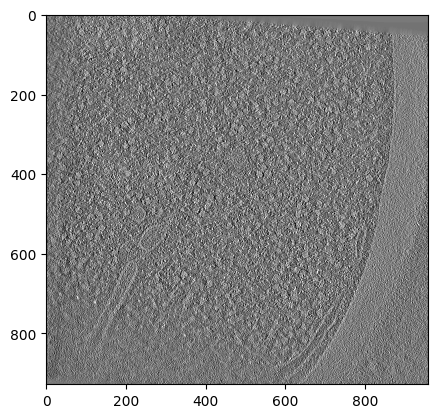

In [3]:
ts_id = "TS_030"

tomo_file = f"{EMPIAR10988_BASE_DIR}/tomograms/{ts_id}.rec"
ribo_coord_file = f"{EMPIAR10988_BASE_DIR}/particle_lists/{ts_id}_cyto_ribosomes.csv"

# tomograms contain large emtpy regions, so we only consider the interesting part
slice_of_interest = empiar10988_ts_to_slice_of_interest[ts_id]
tomo = -1 * load_mrc_data(tomo_file).float()
tomo = tomo[slice_of_interest].clone()


coords = read_empiar10988_coords(ribo_coord_file)
coords.Z -= slice_of_interest.start

plt.imshow(tomo[100], vmin=-2*tomo.std(), vmax=2*tomo.std(), cmap="gray")

### Step 1: Picking a Single Ribosome as Prompt

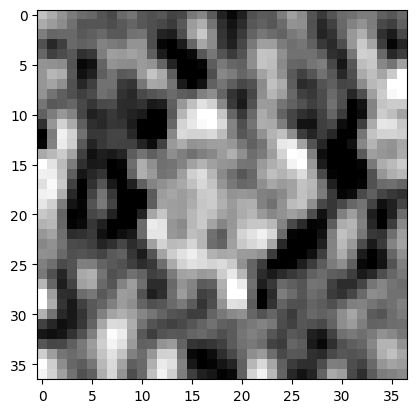

In [4]:
# extract all ribosomes as subtomos of shape (37, 37, 37); this shape is the one needed for the TomoTwin prompt encoder
all_ribo_subtomos = []
for coord in coords[["X", "Y", "Z"]].values.astype(int):
    x, y, z = coord
    subtomo = tomo[
        z-18:z+19,
        y-18:y+19,
        x-18:x+19
    ]
    # some ribosomes are at the edge of the tomogram, so we skip them
    if not subtomo.shape == (37, 37, 37):
        continue
    all_ribo_subtomos.append(subtomo)
    
# you can choose any of the ribo subtomos as prompt
prompt = all_ribo_subtomos[300]
prompt_subtomos_dict = {"cyto_ribosome": prompt}

# inspect prompt
prompt_filt = gaussian_filter(prompt, 1)
plt.imshow(prompt_filt[18], vmin=-2*prompt_filt.std(), vmax=2*prompt_filt.std(), cmap="gray")

### Step 2: Applying the Conditional ProPicker Segmentation Model

In [5]:
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"GPU Memory Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
print(f"GPU Memory Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1024**3:.2f} GB")

GPU Memory Allocated: 0.00 GB
GPU Memory Reserved: 0.00 GB
GPU Memory Free: 7.78 GB


Model config:
{'identifier': 'SiameseNet', 'network_config': {'output_channels': 32, 'dropout': 0.2, 'repeat_layers': 0, 'norm_name': 'GroupNorm', 'norm_kwargs': {'num_groups': 64, 'num_channels': 1024}, 'gem_pooling_p': 0}, 'train_config': {'loss': 'TripletLoss', 'tl_margin': 0.539, 'miner': True, 'miner_margin': 0.734, 'learning_rate': 5.945e-05, 'optimizer': 'Adam', 'weight_decay': 0, 'batchsize': 35, 'patience': 50, 'aug_train_shift_distance': 2}, 'distance': 'COSINE'}
Successfully loaded model weights


Inference (1 prompts): 100%|██████████████████████████████| 1523/1523 [31:54<00:00,  1.26s/it]


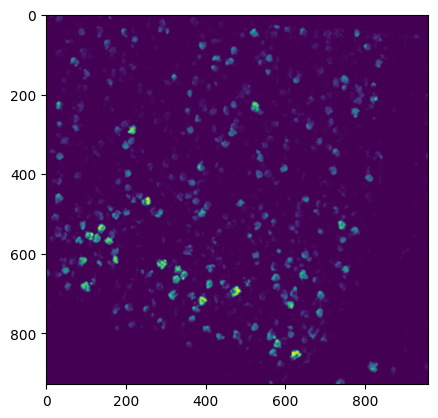

In [6]:
device = "cuda:0"

model = ProPicker.load_from_checkpoint(PROPICKER_MODEL_FILE, map_location="cpu").to(device)
model = model.to(device).eval()
model.freeze()
pred_locmap_dict = get_pred_locmap_dict(
    model, 
    tomo, 
    prompt_subtomos_dict=prompt_subtomos_dict, 
    tomotwin_model_file=TOMOTWIN_MODEL_FILE,  # tomotwin encoder is used to embed prompts in prompt_subtomos_dict
    subtomo_size=64,  # propicker processes the tomogram in subtomos of this size 
    subtomo_overlap=32,  # overlap of the subtomos, you can also reduce this
    batch_size=4,
    mean_pool_locmaps=0,  # you can use this to blur the model outputs, which can help with clustering and may remove some false positives; for crowded tomos such as EMPIAR10988, this is not recommended as it may lead to overlapping particle clusters
)

torch.cuda.empty_cache()

plt.imshow(pred_locmap_dict["cyto_ribosome"][100])

In [7]:
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"GPU Memory Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
print(f"GPU Memory Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1024**3:.2f} GB")

GPU Memory Allocated: 0.39 GB
GPU Memory Reserved: 0.41 GB
GPU Memory Free: 7.40 GB


> The batch size was reduced from 16 to 4 due to hardware limitations.

> The inference time is now 3× longer.

### Step 3: Cluster-Based Picking

Apply thresholding and clustering to the ProPicker segmentation map to pick ribosomes. By tuning the hyperparameters for cluster-based picking, i.e. `binarization_threshold`, `min_cluster_size` and `max_cluster_size`, we can trade off precision and recall:
- `binarization_threshold`: The threshold for binarizing the ProPicker segmentation map. A smaller threshold will result in large clusters and higher recall, whereas a larger threshold will result in smaller clusters and higher precision. You can tune this such that the binarized locmap segments the particles well.
- `min_cluster_size`, `max_cluster_size`: We discard clusters with fewer than `min_cluster_size` or more than `max_cluster_size` particles. These parameters can be used to filter out false positives (improve precision), or to enforce a certain size distribution of the picked particles. If you choose a large `binarization_threshold`, you typically have to decrease `min_cluster_size` and `max_cluster_size` to pick enough particles.

In [8]:
binarization_thresh = 0.25  
binary_locmap = pred_locmap_dict["cyto_ribosome"] > binarization_thresh
# apply clustering to thresholded locmap
cluster_centroids = get_cluster_centroids_df(binary_locmap)
print(f"Number of clusters: {len(cluster_centroids)}")
print(cluster_centroids.head(5))

Number of clusters: 1819
       X     Y    Z  size
0  724.0  39.0  3.0   811
1  747.0  38.0  1.0   333
2  826.0  40.0  0.0     2
3  700.0  45.0  8.0  2008
4  785.0  45.0  5.0  1015


In [9]:
# you can choose the cluster sizes based on particle sizes or using statistics of the cluster sizes, here we use the former and choose the cluster sizes based on the volume of a sphere with radius 20 voxels which is approximately the size of a ribosome
ball_volume = 4/3 * torch.pi * (24/2)**3  
min_cluster_size = 0.1 * ball_volume  
max_cluster_size = 1.2 * ball_volume 
# discard small and large clusters (cluster size is in voxels)
cluster_centroids_filt = cluster_centroids[
    (min_cluster_size <= cluster_centroids["size"]) & (cluster_centroids["size"] <= max_cluster_size)
]
print(f"Number of clusters: {len(cluster_centroids_filt)}")
print(cluster_centroids_filt.head(5))

Number of clusters: 767
       X     Y     Z  size
0  724.0  39.0   3.0   811
3  700.0  45.0   8.0  2008
4  785.0  45.0   5.0  1015
5  802.0  44.0  11.0  1852
6  847.0  47.0   6.0  1047


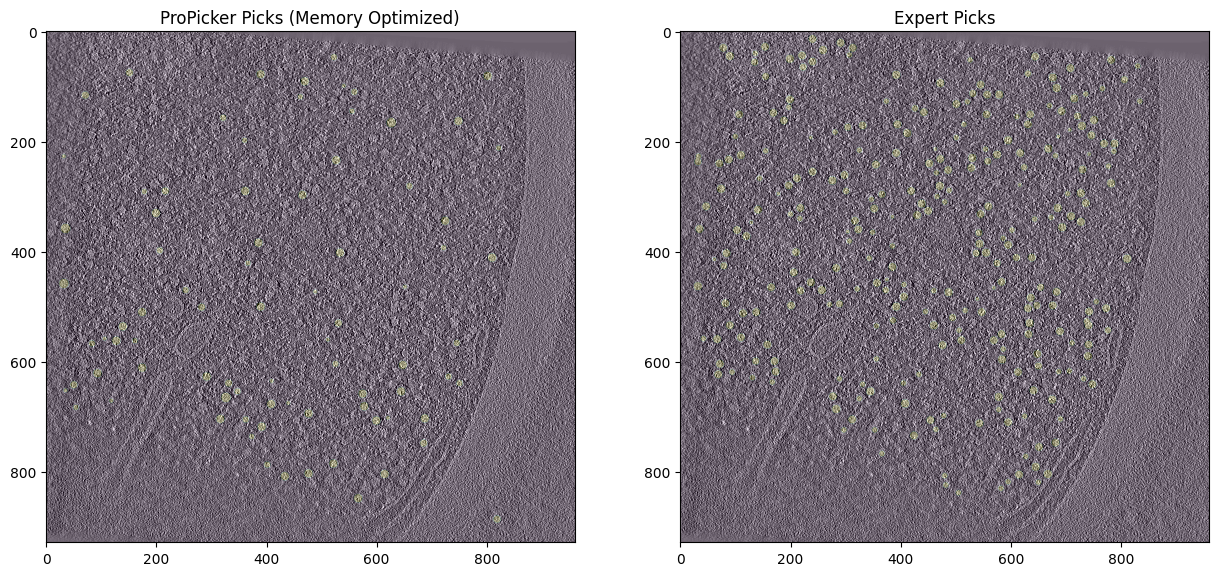

In [ ]:
import numpy as np

slice_to_show = 100

radius = 9
z_min, z_max = slice_to_show - radius, slice_to_show + radius
visible_picks = cluster_centroids_filt[
    (cluster_centroids_filt['Z'] >= z_min) & (cluster_centroids_filt['Z'] <= z_max)
].copy()

picks_slice = torch.zeros((tomo.shape[1], tomo.shape[2]), dtype=torch.bool)

for _, row in visible_picks.iterrows():
    x, y, z = int(row['X']), int(row['Y']), int(row['Z'])
    
    dz = abs(z - slice_to_show)
    if dz < radius:
        r_slice = int(np.sqrt(radius**2 - dz**2))
        
        yy, xx = np.ogrid[-r_slice:r_slice+1, -r_slice:r_slice+1]
        circle = xx**2 + yy**2 <= r_slice**2
        
        y_start, y_end = max(0, y-r_slice), min(tomo.shape[1], y+r_slice+1)
        x_start, x_end = max(0, x-r_slice), min(tomo.shape[2], x+r_slice+1)
        
        circle_y_start = max(0, r_slice-y)
        circle_x_start = max(0, r_slice-x)
        circle_y_end = circle_y_start + (y_end - y_start)
        circle_x_end = circle_x_start + (x_end - x_start)
        
        picks_slice[y_start:y_end, x_start:x_end] |= torch.from_numpy(
            circle[circle_y_start:circle_y_end, circle_x_start:circle_x_end]
        )

# expert picks del dataset
expert_picks = load_mrc_data(f"{EMPIAR10988_BASE_DIR}/labels/{ts_id}_cyto_ribosomes.mrc")[slice_of_interest].bool()

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].set_title("ProPicker Picks (Memory Optimized)")
ax[0].imshow(tomo[slice_to_show].cpu() if torch.is_tensor(tomo) else tomo[slice_to_show], vmin=-2*tomo.std(), vmax=2*tomo.std(), cmap="gray")
ax[0].imshow(picks_slice.cpu(), alpha=0.15)
ax[1].set_title("Expert Picks")
ax[1].imshow(tomo[slice_to_show].cpu() if torch.is_tensor(tomo) else tomo[slice_to_show], vmin=-2*tomo.std(), vmax=2*tomo.std(), cmap="gray")
ax[1].imshow(expert_picks[slice_to_show], alpha=0.15)

### Metric-Based Evaluation of Picks

Computing picking metrics like the F1 score or Precision requires a true-positive criterion.
We use the same one as the authors of TomoTwin, that is, a pick is considered a true positive if a bounding box around is has an intersection-over-union (IoU) of at least 0.6 with a bounding box around and expert pick. 
The bounding box size should be chosen according to the particle size. For the ribosomes, we use a bounding box of 37x37x37 voxels. This true-positive criterion (which we used throughout our paper for consistency) is a bit stricter the one used in the [DeePiCt paper](https://www.nature.com/articles/s41592-022-01746-2), in which the the EMPIAR-10988 dataset was proposed, so we get lower F1 scores.

In [12]:
bbox_size = 37
coords["height"] = coords["width"] = coords["depth"] = bbox_size
cluster_centroids_filt["height"] = cluster_centroids_filt["width"] = cluster_centroids_filt["depth"] = bbox_size

In [13]:
# add class information to the picks so they can be matched with the corresponding expert picks
cluster_centroids_filt["class"] = "cyto_ribosome"

evaluate_picks(
    pred_positions=cluster_centroids_filt,
    gt_positions=coords,
    iou_thresh=0.6,  # a prediction is considered a true positive if the IoU is above this threshold
)

{'cyto_ribosome': {'F1': 0.30738971621241923,
  'Recall': 0.1965504850880345,
  'Precision': 0.7048969072164949,
  'TruePositiveRate': 0.1965504850880345,
  'TP': 547,
  'FP': 229,
  'FN': 2236}}

If you have a tomogram with expert picks, you can tune the binarization and size thresholds used for cluster-based picking. This is the best-case F1 which we report in our paper.

In [14]:
get_best_case_cluster_based_picking_performance(
    pred_locmap_dict=pred_locmap_dict,
    optimize_thresh=True, # whether to optimize the binarization threshold
    n_thresh_steps=10,  # how many binarization thresholds to try between 0 and the max value in the locmap
    n_size_steps=5,  # how many min and max cluster sizes to try for each binarization threshold
    gt_positions=coords,
    metric="F1",  # you can optimize for "F1", "Precision" or "Recall"
    num_workers=0,
    iou_thresh=0.6, 
)       

Running evaluation with 1 workers
Optimizing threshold for cyto_ribosome between 2.0298894441532072e-16 and 0.9732994437217712


cyto_ribosome (Best F1: 0.35): 100%|████████████████████████| 250/250 [02:02<00:00,  2.04it/s]


{'cyto_ribosome': {'F1': 0.34920634920634924,
  'Recall': 0.2648221343873518,
  'Precision': 0.5125173852573018,
  'TruePositiveRate': 0.2648221343873518,
  'TP': 737,
  'FP': 701,
  'FN': 2046,
  'min_size': 107.5,
  'max_size': 17645.25,
  'positions': '          X      Y      Z   size  metric_best  predicted_class  height  width  depth\n0     747.0   39.0    2.0    738          1.0                0      37     37     37\n1     724.0   39.0    4.0   1524          1.0                0      37     37     37\n3     701.0   46.0    8.0   3191          1.0                0      37     37     37\n4     784.0   46.0    5.0   1700          1.0                0      37     37     37\n5     799.0   57.0   25.0  12550          1.0                0      37     37     37\n6     845.0   61.0   30.0   9209          1.0                0      37     37     37\n7     931.0   51.0    3.0    752          1.0                0      37     37     37\n8     881.0   50.0    4.0    219          1.0           

## 6. Conclusion

ProPicker demonstrates effective out-of-the-box performance for prompt-based ribosome picking in the EMPIAR-10988 dataset. The model's flexibility allows fine-tuning of detection parameters through binarization and cluster size thresholds, enabling users to balance precision and recall based on specific experimental requirements.

Key findings from this analysis:
- **Prompt-based segmentation** provides an intuitive and effective approach to particle picking without requiring extensive training data
- **Adjustable thresholds** offer control over the trade-off between false positives and false negatives
- **Architecture design** (SAM-based encoder-decoder with prompt conditioning) enables generalization across different cryo-ET datasets

The approach shows promise for broader applications in automated macromolecule localization, particularly in scenarios where labeled training data is limited or unavailable.